# Passive Shimming Workshop Notebook

**DELTA DIY MRI Workshop — Learn → Design → Build → Shim**

**Kernel for this notebook:** `DIY MRI Passive Shimming Python 3.11`  
**Environment folder:** `.diy-mri-shimming`

This notebook turns the passive-shimming workflow into a teaching sequence for the workshop.

By the end, you should be able to:

1. explain why B0 shimming matters for MRI,
2. connect field variation in tesla / ppm / Hz to image quality,
3. understand how passive shim magnets add a compensating field,
4. compare a greedy local search and a genetic algorithm search,
5. configure a shim tray from either a simple circular geometry or an external STL file,
6. run the published `passive-shimming` package workflow and export shim-tray outputs.

The practical target is a low-field DIY MRI system where the measured field map is loaded from `./data`, and the shim tray geometry can optionally be supplied from:

```text
./data/delta1_first_layer_shim_tray.STL
```

---

## Workshop philosophy

```text
Learn  →  understand the physics and optimization idea
Design →  define the field map, shim magnets, and tray geometry
Build  →  compute basis fields and solve the optimization problem
Shim   →  export the final shim collections and tray files
```


## Setup: use the passive-shimming kernel

This notebook **does not install packages inside the notebook**.

Instead, first run the workshop setup notebook:

```text
console/notebooks/01_setup_environment.ipynb
```

That setup notebook creates two separate environments:

```text
.diy-mri-workshop   → acquisition / console notebooks, PyPulseq, MRZeroCore, numpy<2
.diy-mri-shimming   → passive-shimming==0.0.1, pymoo, magpylib, STL tools, numpy>=2
```

For this notebook, select this Jupyter kernel:

```text
DIY MRI Passive Shimming Python 3.11
```

This separation avoids the known NumPy dependency conflict between the acquisition stack and `passive-shimming==0.0.1`.


In [8]:
# Kernel and environment check
#
# Expected kernel:
#   DIY MRI Passive Shimming Python 3.11
#
# Expected environment folder:
#   .diy-mri-shimming

from pathlib import Path
import platform
import sys

print("Passive-shimming kernel check")
print("------------------------------")
print("Python executable:", sys.executable)
print("Python version   :", sys.version.split()[0])
print("Platform         :", platform.platform())
print("Working directory:", Path.cwd())

exe = sys.executable.replace("\\", "/")

if ".diy-mri-workshop" in exe:
    raise RuntimeError(
        "This notebook is using .diy-mri-workshop, which is reserved for acquisition notebooks. "
        "Switch the kernel to 'DIY MRI Passive Shimming Python 3.11'."
    )

if ".diy-mri-shimming" in exe:
    print("PASS: running inside .diy-mri-shimming")
else:
    print("WARNING: '.diy-mri-shimming' was not found in sys.executable.")
    print("If imports fail below, switch to the kernel: DIY MRI Passive Shimming Python 3.11")


Passive-shimming kernel check
------------------------------
Python executable: /Users/sairamgeethanath/Documents/Contributions/Tools/Projects/adelpha/.diy-mri-shimming/bin/python
Python version   : 3.11.9
Platform         : macOS-26.6.2-arm64-arm-64bit
Working directory: /Users/sairamgeethanath/Documents/Contributions/Tools/Projects/adelpha/console/notebooks/passive_shimming
PASS: running inside .diy-mri-shimming


## Setup: import packages and verify workflow modules

The current `passive-shimming` PyPI package exposes the workflow through reusable modules such as:

```text
shimming_io
shimming_geometry
shimming_basis
shimming_optimization
shimming_reporting
shimming_export
```

This cell verifies that the active kernel can import the package stack and that NumPy is compatible with `passive-shimming==0.0.1`.


In [10]:
from pathlib import Path
import sys
import importlib
import inspect

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("Package and workflow-module check")
print("---------------------------------")
print("Python executable:", sys.executable)
print("Python version   :", sys.version.split()[0])
print("NumPy version    :", np.__version__)

numpy_major = int(np.__version__.split(".")[0])
if numpy_major < 2:
    raise RuntimeError(
        "passive-shimming==0.0.1 requires NumPy >= 2.0. "
        "Switch to the 'DIY MRI Passive Shimming Python 3.11' kernel."
    )
else:
    print("PASS: NumPy is compatible with passive-shimming==0.0.1")

modules_to_check = [
    "shimming_io",
    "shimming_geometry",
    "shimming_basis",
    "shimming_optimization",
    "shimming_reporting",
    "shimming_export",
    "pymoo",
    "magpylib",
    "trimesh",
    "plotly",
]

loaded = {}
failed = []

for module_name in modules_to_check:
    try:
        loaded[module_name] = importlib.import_module(module_name)
        module_file = getattr(loaded[module_name], "__file__", "built-in")
        print(f"PASS: {module_name:22s} -> {module_file}")
    except Exception as exc:
        failed.append((module_name, exc))
        print(f"FAIL: {module_name:22s} -> {exc!r}")

if failed:
    names = ", ".join(name for name, _ in failed)
    raise RuntimeError(
        "One or more passive-shimming dependencies failed to import: "
        f"{names}. Re-run the setup notebook and use the shimming kernel."
    )

# Main workflow classes
from shimming_io import ShimmingRun, FieldMap
from shimming_geometry import TrayGeometry, ShimMagnet, CandidateTray
from shimming_basis import ShimBasis
from shimming_optimization import ShimOptimizationProblem, ShimOptimizer
from shimming_reporting import ShimmingReporter
from shimming_export import ShimCollectionExporter, ShimTrayExporter

print("PASS: passive-shimming workflow imports completed.")


Package and workflow-module check
---------------------------------
Python executable: /Users/sairamgeethanath/Documents/Contributions/Tools/Projects/adelpha/.diy-mri-shimming/bin/python
Python version   : 3.11.9
NumPy version    : 2.4.6
PASS: NumPy is compatible with passive-shimming==0.0.1
PASS: shimming_io            -> /Users/sairamgeethanath/Documents/Contributions/Tools/Projects/adelpha/.diy-mri-shimming/lib/python3.11/site-packages/shimming_io.py
PASS: shimming_geometry      -> /Users/sairamgeethanath/Documents/Contributions/Tools/Projects/adelpha/.diy-mri-shimming/lib/python3.11/site-packages/shimming_geometry.py
PASS: shimming_basis         -> /Users/sairamgeethanath/Documents/Contributions/Tools/Projects/adelpha/.diy-mri-shimming/lib/python3.11/site-packages/shimming_basis.py
PASS: shimming_optimization  -> /Users/sairamgeethanath/Documents/Contributions/Tools/Projects/adelpha/.diy-mri-shimming/lib/python3.11/site-packages/shimming_optimization.py
PASS: shimming_reporting    

# Part I — Learn: why B0 shimming matters

MRI assumes that spins precess near a known main magnetic field, `B0`.

If the field is not uniform, spins at different positions have different resonance frequencies:

$$
\Delta f(\mathbf{r}) = \bar{\gamma}\,\Delta B(\mathbf{r})
$$

where:

- $\Delta B(\mathbf{r})$ is the field error in tesla,
- $\bar{\gamma}$ is the proton gyromagnetic ratio in Hz/T,
- $\Delta f(\mathbf{r})$ is the frequency offset in Hz.

At low field, the main frequency is lower, but the scanner can still be sensitive to field variation because narrow receive bandwidth, longer readouts, and long echo trains can make off-resonance visible.

For the DELTA system:

$$
B_0 = 0.2516\ \mathrm{T}
$$

and approximately:

$$
\bar{\gamma} = 42.577\times 10^6\ \mathrm{Hz/T}
$$

In [11]:
# Basic low-field frequency numbers

B0_T = 0.2516
GAMMABAR_HZ_PER_T = 42.577478518e6

f0_Hz = GAMMABAR_HZ_PER_T * B0_T

print("Low-field resonance calculation")
print("--------------------------------")
print(f"B0                  : {B0_T:.4f} T")
print(f"gamma_bar           : {GAMMABAR_HZ_PER_T/1e6:.6f} MHz/T")
print(f"Larmor frequency f0 : {f0_Hz/1e6:.3f} MHz")

# Conversion examples
for ppm in [10, 50, 100, 500, 1000]:
    dB_T = B0_T * ppm * 1e-6
    df_Hz = GAMMABAR_HZ_PER_T * dB_T
    print(f"{ppm:4d} ppm at {B0_T:.4f} T -> ΔB = {dB_T*1e6:8.3f} µT -> Δf = {df_Hz:8.1f} Hz")

Low-field resonance calculation
--------------------------------
B0                  : 0.2516 T
gamma_bar           : 42.577479 MHz/T
Larmor frequency f0 : 10.712 MHz
  10 ppm at 0.2516 T -> ΔB =    2.516 µT -> Δf =    107.1 Hz
  50 ppm at 0.2516 T -> ΔB =   12.580 µT -> Δf =    535.6 Hz
 100 ppm at 0.2516 T -> ΔB =   25.160 µT -> Δf =   1071.2 Hz
 500 ppm at 0.2516 T -> ΔB =  125.800 µT -> Δf =   5356.2 Hz
1000 ppm at 0.2516 T -> ΔB =  251.600 µT -> Δf =  10712.5 Hz


## Work it by hand: ppm to Hz

Suppose the field variation inside the useful imaging region is **500 ppm peak-to-peak** at `0.2516 T`.

1. Convert 500 ppm to tesla:

$$
\Delta B = B_0 \times 500\times 10^{-6}
$$

2. Convert that field variation to Hz:

$$
\Delta f = \bar{\gamma}\Delta B
$$

Answer:

$$
\Delta B = 0.2516 \times 500\times 10^{-6} = 1.258\times 10^{-4}\ \mathrm{T}
$$

$$
\Delta f \approx 42.577\times10^6 \times 1.258\times10^{-4} \approx 5357\ \mathrm{Hz}
$$

So a 500 ppm field spread at 0.2516 T corresponds to about **5.36 kHz** of frequency spread.

## Passive shimming idea

Passive shimming places small permanent magnets around the imaging region.

Each candidate magnet contributes a field pattern:

$$
B_i(\mathbf{r})
$$

If each magnet can be placed with positive polarity, negative polarity, or omitted, then each candidate has a state:

$$
s_i \in \{-1, 0, +1\}
$$

The total predicted shim field is:

$$
B_\mathrm{shim}(\mathbf{r}) = \sum_i s_i B_i(\mathbf{r})
$$

The corrected field is:

$$
B_\mathrm{total}(\mathbf{r}) = B_\mathrm{measured}(\mathbf{r}) + B_\mathrm{shim}(\mathbf{r})
$$

The optimization problem is to choose the states $s_i$ that make $B_\mathrm{total}$ more homogeneous.

In [12]:
# Toy passive shimming example with three measured positions and two shim candidates.
# This is deliberately small enough to work by hand.

B_measured_uT = np.array([-4.0, +2.0, +6.0])  # field error at three points, in microtesla

# Candidate fields in microtesla if placed with positive polarity.
# state = +1 -> add this pattern
# state = -1 -> subtract this pattern
# state =  0 -> no magnet
basis_uT = np.array([
    [ 1.0,  0.0, -1.0],   # candidate 1
    [-1.0, -1.0, +2.0],   # candidate 2
])

allowed_states = [-1, 0, +1]

def objective_std(states):
    states = np.asarray(states)
    B_shim = states @ basis_uT
    B_total = B_measured_uT + B_shim
    return np.std(B_total), B_total

rows = []
for s0 in allowed_states:
    for s1 in allowed_states:
        std, B_total = objective_std([s0, s1])
        rows.append({
            "s1": s0,
            "s2": s1,
            "B_total_uT": np.array2string(B_total, precision=1),
            "std_uT": std,
        })

results = pd.DataFrame(rows).sort_values("std_uT").reset_index(drop=True)
results

,s1,s2,B_total_uT,std_uT
0,1,-1,[-2. 3. 3.],2.357023
1,0,-1,[-3. 3. 4.],3.091206
2,1,0,[-3. 2. 5.],3.299832
3,-1,-1,[-4. 3. 5.],3.858612
4,0,0,[-4. 2. 6.],4.109609
5,1,1,[-4. 1. 7.],4.496913
6,-1,0,[-5. 2. 7.],4.921608
7,0,1,[-5. 1. 8.],5.312459
8,-1,1,[-6. 1. 9.],6.128259


## What the toy example teaches

The toy table shows the core idea of passive shimming:

```text
try candidate magnet states → predict total field → score homogeneity → choose best state vector
```

For a real tray, the number of candidate locations may be large. With three possible states per candidate, the full search space grows as:

$$
3^N
$$

where $N$ is the number of candidate shim locations.

That becomes too large to brute force, so we combine two search ideas:

1. **Greedy search** for a fast, reasonable starting point.
2. **Genetic algorithm** for a broader search around many possible combinations.

# Part II — Learn: greedy and genetic search

## Greedy search

A greedy algorithm makes the best local move available right now.

For passive shimming, one simple greedy idea is:

```text
start with no magnets
try flipping one candidate to -1, 0, or +1
keep the change if the field improves
repeat until no simple change helps
```

Greedy search is fast and intuitive, but it can get stuck in a local solution.

## Genetic algorithm

A genetic algorithm keeps a population of possible solutions.

Each solution is a vector of shim states:

$$
[s_1, s_2, \dots, s_N]
$$

The algorithm repeatedly:

1. evaluates each solution,
2. keeps or favors better solutions,
3. recombines / mutates solutions,
4. searches for lower field variation.

In this workshop workflow, the greedy result is useful as a strong initial guess for the genetic algorithm.

Greedy solution states: [ 1  1 -1  0]
Initial std: 2.546
Final std  : 0.514


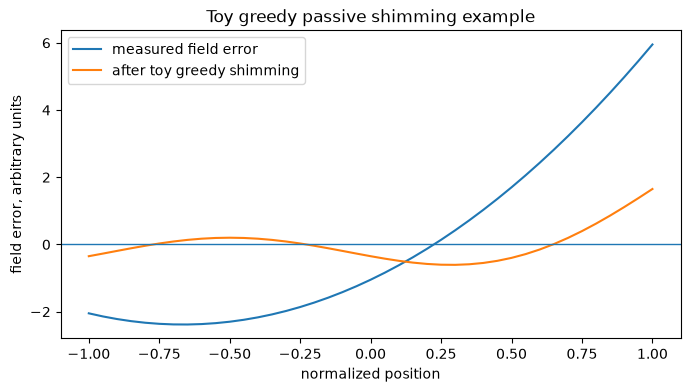

In [13]:
# Toy greedy search: four candidate magnets, each can be -1, 0, +1.
# We make a synthetic 1D field and synthetic basis fields.

rng = np.random.default_rng(42)

x = np.linspace(-1, 1, 41)
B_measured = 4*x + 3*x**2 - np.mean(4*x + 3*x**2)

basis = np.vstack([
    -3*x,                       # candidate helps linear term
    -2*(x**2 - np.mean(x**2)),   # candidate helps quadratic term
    0.8*np.sin(np.pi*x),         # candidate may or may not help
    0.5*np.cos(2*np.pi*x),       # candidate may or may not help
])

allowed_states = np.array([-1, 0, +1])

def score(states):
    B_total = B_measured + states @ basis
    return np.std(B_total)

states = np.zeros(basis.shape[0], dtype=int)
history = []

improved = True
while improved:
    improved = False
    current_score = score(states)
    best_trial = states.copy()
    best_score = current_score

    for i in range(len(states)):
        for s in allowed_states:
            trial = states.copy()
            trial[i] = s
            trial_score = score(trial)
            if trial_score < best_score:
                best_score = trial_score
                best_trial = trial.copy()

    if best_score < current_score:
        states = best_trial
        improved = True
        history.append((states.copy(), best_score))

print("Greedy solution states:", states)
print(f"Initial std: {score(np.zeros_like(states)):.3f}")
print(f"Final std  : {score(states):.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, B_measured, label="measured field error")
ax.plot(x, B_measured + states @ basis, label="after toy greedy shimming")
ax.axhline(0, linewidth=1)
ax.set_xlabel("normalized position")
ax.set_ylabel("field error, arbitrary units")
ax.set_title("Toy greedy passive shimming example")
ax.legend()
plt.show()

Toy GA best states: [ 1  1 -1  0]
Best std: 0.514


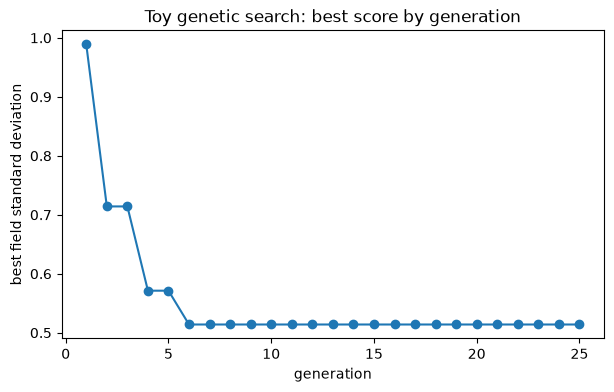

In [14]:
# Toy genetic-algorithm-style search without requiring pymoo yet.
# This is only for intuition: population + mutation + selection.

rng = np.random.default_rng(7)
N = basis.shape[0]
P = 20
G = 25
mutation_probability = 0.25

population = rng.choice(allowed_states, size=(P, N))
fitness_history = []

for generation in range(G):
    fitness = np.array([score(individual) for individual in population])
    order = np.argsort(fitness)
    population = population[order]
    fitness = fitness[order]
    fitness_history.append(fitness[0])

    # Keep top quarter as parents
    parents = population[: max(2, P//4)]

    # Refill population with crossover and mutation
    children = [parents[0].copy()]
    while len(children) < P:
        p1, p2 = parents[rng.integers(len(parents), size=2)]
        mask = rng.random(N) < 0.5
        child = np.where(mask, p1, p2)

        mutate = rng.random(N) < mutation_probability
        child[mutate] = rng.choice(allowed_states, size=np.sum(mutate))
        children.append(child)

    population = np.array(children)

best_states = population[0]
print("Toy GA best states:", best_states)
print(f"Best std: {score(best_states):.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, len(fitness_history)+1), fitness_history, marker="o")
ax.set_xlabel("generation")
ax.set_ylabel("best field standard deviation")
ax.set_title("Toy genetic search: best score by generation")
plt.show()

# Part III — Design: configure the real passive-shimming run

The uploaded workflow script is organized as a clean top-level API:

```text
0. Load measured field
1. Define tray geometry
2. Define shim magnet
3. Construct candidate tray
4. Define optimization problem
5. Precompute shim basis
6. Pre-shimming report
7. Run optimizer
8. Post-shimming report
9. Build/save Magpylib collections
10. Export physical STL trays
11. Reload and verify exported STL trays
```

This notebook keeps the same structure but turns each stage into a workshop checkpoint.

In [16]:
# Run control and paths

STOP_AFTER_STEP = None
RANDOM_SEED = 42

SHOW_INPUT_FIELD = True
SHOW_TRAY_GEOMETRY = True
SHOW_CANDIDATES = True
SHOW_FINAL_COLLECTIONS = True
SHOW_EXPORTED_STLS = True

# Greedy diagnostic perturbation sizes used before the GA.
PERTURBATION_SIZES = (2, 3, 5, 8, 10)

# Data paths inside the Adelpha workshop repo.
DATA_DIR = Path("./data")
FMR_DATA_FILE = DATA_DIR / "Exp_1044_2026831.npy"
EXTERNAL_STL_FILE = DATA_DIR / "delta1_first_layer_shim_tray.STL"
OUTPUT_ROOT = DATA_DIR / "shimming_runs"

print("Passive shimming paths")
print("----------------------")
print("DATA_DIR         :", DATA_DIR.resolve())
print("FMR_DATA_FILE    :", FMR_DATA_FILE)
print("External STL file:", EXTERNAL_STL_FILE)
print("OUTPUT_ROOT      :", OUTPUT_ROOT)
print()
print("FMR exists?      :", FMR_DATA_FILE.exists())
print("STL exists?      :", EXTERNAL_STL_FILE.exists())

if not FMR_DATA_FILE.exists():
    print("NOTE: Put the measured field-map .npy file in ./data before running the full workflow.")
if not EXTERNAL_STL_FILE.exists():
    print("NOTE: Put delta1_first_layer_shim_tray.STL in ./data if using external tray geometry.")

# The toy examples above can be run without these files.
# The full workflow below requires the field map. The external STL is required only if USE_EXTERNAL_STL=True.


Passive shimming paths
----------------------
DATA_DIR         : /Users/sairamgeethanath/Documents/Contributions/Tools/Projects/adelpha/console/notebooks/passive_shimming/data
FMR_DATA_FILE    : data/Exp_1044_2026831.npy
External STL file: data/delta1_first_layer_shim_tray.STL
OUTPUT_ROOT      : data/shimming_runs

FMR exists?      : True
STL exists?      : True


## Design checkpoint: field-map units

The measured field map can be stored in convenient lab units such as **mm** for position and **mT** for field.

The workflow converts them to SI units:

```text
position scale: mm → m
field scale:    mT → T
```

The field map is then reported in physically meaningful units such as T, mT, µT, ppm, or Hz.

In [17]:
# Experiment inputs

GAMMABAR_HZ_PER_T = 42.577478518e6
MEASURED_POSITION_SCALE_TO_M = 1e-3
MEASURED_FIELD_SCALE_TO_T = 1e-3

print("Experiment inputs")
print("-----------------")
print(f"gamma_bar                 : {GAMMABAR_HZ_PER_T/1e6:.6f} MHz/T")
print(f"position scale to meters  : {MEASURED_POSITION_SCALE_TO_M:g}")
print(f"field scale to tesla      : {MEASURED_FIELD_SCALE_TO_T:g}")

Experiment inputs
-----------------
gamma_bar                 : 42.577479 MHz/T
position scale to meters  : 0.001
field scale to tesla      : 0.001



Passive shimming run initialized
  Run ID: 20260915_114331
  Output directory: data/shimming_runs/20260915_114331
  Random seed: 42

Field-map validation passed
  Samples: 3071
  Mean field: 251.661659 mT
  Peak-to-peak: 3.524208 mT
  Peak-to-peak off-resonance: 150.052 kHz
Loaded field map
----------------
Number of measured positions: 3071
B_T shape                   : (3071,)
Run directory               : data/shimming_runs/20260915_114331


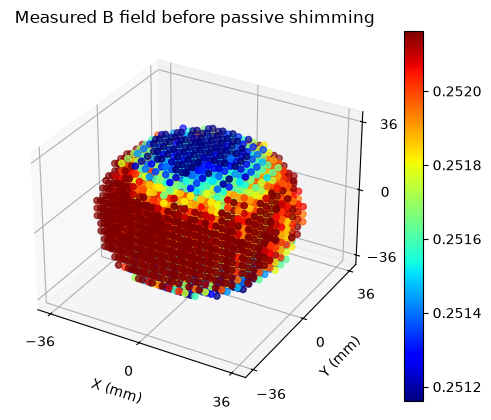

PosixPath('data/shimming_runs/20260915_114331/field_map_config.json')

In [18]:
# Load and validate the measured field map.
# This cell needs ./data/Exp_1044_2026831.npy to exist.

if not FMR_DATA_FILE.exists():
    raise FileNotFoundError(
        f"Measured field-map file was not found: {FMR_DATA_FILE}. "
        "Place the .npy field-map file in ./data before running the full workflow. "
        "You can still run the Learn/toy-example cells above without this file."
    )

run = ShimmingRun(
    output_root=OUTPUT_ROOT,
    random_seed=RANDOM_SEED,
    stop_after_step=STOP_AFTER_STEP,
)

field_map = FieldMap.from_npy(
    filename=FMR_DATA_FILE,
    position_scale_to_m=MEASURED_POSITION_SCALE_TO_M,
    field_scale_to_T=MEASURED_FIELD_SCALE_TO_T,
    gammabar_Hz_per_T=GAMMABAR_HZ_PER_T,
)

field_map.validate()

print("Loaded field map")
print("----------------")
print("Number of measured positions:", len(field_map.positions_m))
print("B_T shape                   :", np.shape(field_map.B_T))
print("Run directory               :", run.run_dir)

if SHOW_INPUT_FIELD:
    field_map.show(title="Measured B field before passive shimming")

run.save_config("field_map", field_map)


# Part IV — Design: tray geometry and shim magnets

The shim tray tells the optimizer where magnets are physically allowed to go.

For the workshop, there are two useful paths:

## Path A — External STL tray

Use the supplied tray geometry:

```text
./data/delta1_first_layer_shim_tray.STL
```

This is the most realistic path because the optimizer is constrained by the actual printable/usable tray design.

## Path B — Simple circular tray

Use a simple circular two-plane tray when the STL file is unavailable or when teaching the geometry first.

The starting circular geometry uses:

```text
tray diameter: 203.3 mm
plane heights: -48.5 mm and +48.5 mm
inner surface separation: 97 mm
```

In [19]:
# Tray geometry inputs
#
# Recommended workshop path:
#   1. Start with USE_EXTERNAL_STL=False so the circular teaching geometry is easy to debug.
#   2. Switch to USE_EXTERNAL_STL=True when ./data/delta1_first_layer_shim_tray.STL is present.

USE_EXTERNAL_STL = False

STL_UNITS = "mm"
TRAY_INNER_SURFACE_SEPARATION_M = 97e-3
STL_MARGIN_M = 0.0

# Used only when USE_EXTERNAL_STL=False.
CIRCULAR_TRAY_DIAMETER_M = 203.3e-3
CIRCULAR_TRAY_HEIGHTS_M = np.array([
    -48.5e-3,
    +48.5e-3,
])

print("Tray geometry mode")
print("------------------")
print("USE_EXTERNAL_STL:", USE_EXTERNAL_STL)
print("External STL    :", EXTERNAL_STL_FILE)
print("STL exists?     :", EXTERNAL_STL_FILE.exists())
print("Circular heights:", CIRCULAR_TRAY_HEIGHTS_M)


Tray geometry mode
------------------
USE_EXTERNAL_STL: False
External STL    : data/delta1_first_layer_shim_tray.STL
STL exists?     : True
Circular heights: [-0.0485  0.0485]


In [22]:
# Create tray geometry

if USE_EXTERNAL_STL:
    if not EXTERNAL_STL_FILE.exists():
        raise FileNotFoundError(
            f"USE_EXTERNAL_STL=True, but {EXTERNAL_STL_FILE} was not found. "
            "Place the STL in ./data or set USE_EXTERNAL_STL=False."
        )

    tray_geometry = TrayGeometry.from_external_stl(
        stl_file=EXTERNAL_STL_FILE,
        separation_m=TRAY_INNER_SURFACE_SEPARATION_M,
        stl_units=STL_UNITS,
        margin_m=STL_MARGIN_M,
    )
else:
    tray_geometry = TrayGeometry.circular(
        diameter_m=CIRCULAR_TRAY_DIAMETER_M,
        heights_m=CIRCULAR_TRAY_HEIGHTS_M,
    )

tray_geometry.validate()

print("PASS: tray geometry created and validated.")

if SHOW_TRAY_GEOMETRY:
    tray_geometry.show()

run.save_config("tray_geometry", tray_geometry)


Tray geometry validation passed
  Mode: circular
  Bottom plane: -48.500 mm
  Top plane: 48.500 mm
  Separation: 97.000 mm
  Usable area: 32461.2 mm^2
PASS: tray geometry created and validated.
Circular TrayGeometry has no STL mesh to display. Candidate magnets can be displayed after CandidateTray.build().


PosixPath('data/shimming_runs/20260915_114331/tray_geometry_config.json')

## Design checkpoint: shim magnet model

Each candidate location uses the same basic magnet model.

Starting values:

```text
material: N45
size:     6.35 mm × 6.35 mm × 3.18 mm
polarization: 1.2 T
```

The optimizer will decide the state of each candidate:

```text
-1 = negative polarity
 0 = no magnet
+1 = positive polarity
```

In [20]:
# Magnet inputs

MAGNET_MATERIAL = "N45"
MAGNET_DIMS_M = np.array([6.35e-3, 6.35e-3, 3.18e-3])
POLARIZATION_T = 1.2

shim_magnet = ShimMagnet(
    material=MAGNET_MATERIAL,
    dimensions_m=MAGNET_DIMS_M,
    polarization_T=POLARIZATION_T,
)

shim_magnet.validate()
run.save_config("shim_magnet", shim_magnet)

print("Shim magnet")
print("-----------")
print("Material      :", MAGNET_MATERIAL)
print("Dimensions mm :", MAGNET_DIMS_M * 1e3)
print("Polarization T:", POLARIZATION_T)


Shim magnet validation passed
  Material: N45
  Dimensions: [6.35 6.35 3.18] mm
  Polarization: 1.200 T
  Footprint area: 40.322 mm^2
Shim magnet
-----------
Material      : N45
Dimensions mm : [6.35 6.35 3.18]
Polarization T: 1.2


In [23]:
# Candidate tray construction settings

RADIAL_SPACING_FACTOR = 1.0
AZIMUTHAL_SPACING_FACTOR = 1.25
USE_SYMMETRY = False
SKIP_CENTER_MAGNETS = False
MAX_CANDIDATES_PER_PLANE = None
REQUIRE_FULL_MAGNET_INSIDE = True

candidate_tray = CandidateTray(
    tray_geometry=tray_geometry,
    shim_magnet=shim_magnet,
    radial_spacing_factor=RADIAL_SPACING_FACTOR,
    azimuthal_spacing_factor=AZIMUTHAL_SPACING_FACTOR,
    symmetry=USE_SYMMETRY,
    skip_center_magnets=SKIP_CENTER_MAGNETS,
    max_candidates_per_plane=MAX_CANDIDATES_PER_PLANE,
    require_full_magnet_inside=REQUIRE_FULL_MAGNET_INSIDE,
)

candidate_tray.build()
candidate_tray.print_statistics()

run.save_report("candidate_geometry", candidate_tray.statistics())

if SHOW_CANDIDATES:
    candidate_tray.show()


Tray geometry validation passed
  Mode: circular
  Bottom plane: -48.500 mm
  Top plane: 48.500 mm
  Separation: 97.000 mm
  Usable area: 32461.2 mm^2

Shim magnet validation passed
  Material: N45
  Dimensions: [6.35 6.35 3.18] mm
  Polarization: 1.200 T
  Footprint area: 40.322 mm^2

Shim-ring geometry:
  Magnet dimensions [mm]: [6.35 6.35 3.18]
  Polarization: 1.200 T
  Radial pitch: 8.980 mm
  Azimuthal target pitch: 7.938 mm
  Maximum candidate-center radius: 97.160 mm
  Radial levels including center: 11
Ring 1: radius=8.98 mm | full-circle candidates=7 | accepted=7
Ring 2: radius=17.96 mm | full-circle candidates=14 | accepted=14
Ring 3: radius=26.94 mm | full-circle candidates=21 | accepted=21
Ring 4: radius=35.92 mm | full-circle candidates=28 | accepted=28
Ring 5: radius=44.90 mm | full-circle candidates=35 | accepted=35
Ring 6: radius=53.88 mm | full-circle candidates=42 | accepted=42
Ring 7: radius=62.86 mm | full-circle candidates=49 | accepted=49
Ring 8: radius=71.84 mm 

# Part V — Build: optimization objective and basis fields

## Optimization objective

We want the corrected field to be more homogeneous.

This workflow combines two measures:

1. **standard deviation** of the field, and
2. **percentile range**, such as P99 − P01.

The percentile range is useful because it is less dominated by a single extreme point than the absolute min/max.

The objective is approximately:

$$
\mathrm{score} = w_\mathrm{std}\,\sigma(B) + w_\mathrm{range}\,[P_{99}(B) - P_{1}(B)]
$$

In [24]:
# Optimization inputs

OPTIMIZATION_STATES = (-1, 0, +1)

POPULATION_SIZE = 500
NUM_GENERATIONS = 100

STD_WEIGHT = 0.75
P01_P99_WEIGHT = 0.25
LOW_PERCENTILE = 1.0
HIGH_PERCENTILE = 99.0

optimization_problem = ShimOptimizationProblem(
    field_map=field_map,
    candidate_tray=candidate_tray,
    allowed_states=OPTIMIZATION_STATES,
    std_weight=STD_WEIGHT,
    percentile_range_weight=P01_P99_WEIGHT,
    low_percentile=LOW_PERCENTILE,
    high_percentile=HIGH_PERCENTILE,
)

optimization_problem.validate()
run.save_config("optimization_problem", optimization_problem)

print("Optimization problem")
print("--------------------")
print("Allowed states       :", OPTIMIZATION_STATES)
print("Population size      :", POPULATION_SIZE)
print("Generations          :", NUM_GENERATIONS)
print("Std weight           :", STD_WEIGHT)
print("Percentile weight    :", P01_P99_WEIGHT)
print(f"Percentile range     : P{LOW_PERCENTILE:g} to P{HIGH_PERCENTILE:g}")

Optimization problem
--------------------
Allowed states       : (-1, 0, 1)
Population size      : 500
Generations          : 100
Std weight           : 0.75
Percentile weight    : 0.25
Percentile range     : P1 to P99


## Basis-field idea

A slow approach would recompute the magnetic field from every magnet during every optimization step.

A faster approach is to precompute a basis:

```text
candidate 1 field at all measured positions
candidate 2 field at all measured positions
candidate 3 field at all measured positions
...
```

Then any proposed shim state vector is just a weighted sum:

$$
B_\mathrm{shim} = \mathbf{s}^T \mathbf{B}_\mathrm{basis}
$$

This is the computational bridge between magnet physics and optimization.

In [25]:
# Precompute shim basis

NUM_BASIS_VALIDATION_TESTS = 5
BASIS_VALIDATION_ATOL_T = 1e-10
BASIS_VALIDATION_RTOL = 1e-8

shim_basis = ShimBasis(
    field_map=field_map,
    candidate_tray=candidate_tray,
)

shim_basis.compute()

shim_basis.validate(
    n_tests=NUM_BASIS_VALIDATION_TESTS,
    atol_T=BASIS_VALIDATION_ATOL_T,
    rtol=BASIS_VALIDATION_RTOL,
    random_seed=RANDOM_SEED,
)

shim_basis.save(run.path("shim_basis.npz"))
run.save_report("shim_basis", shim_basis.statistics())

optimization_problem.attach_basis(shim_basis)

print("PASS: shim basis computed, validated, saved, and attached to optimization problem.")

PASS: shim basis computed, validated, saved, and attached to optimization problem.


# Part VI — Build: pre-shim report and optimization

Before optimizing, measure how bad the starting field is.

Then run a two-stage search:

1. **diagnose / greedy search** to find a useful starting state vector,
2. **genetic algorithm** to refine the solution.

This matches the workshop idea:

```text
simple intuition first → scalable optimizer second
```

In [26]:
# Pre-shimming report

reporter = ShimmingReporter(
    field_map=field_map,
    optimization_problem=optimization_problem,
)

pre_report = reporter.evaluate(
    B_total_T=field_map.B_T,
    label="pre_shim",
)

reporter.print_report(pre_report)
reporter.save_report(pre_report, run.path("pre_shim_report.json"))


Shimming report — pre_shim
Field points: 3071
Mean field: 251.661659 mT
Standard deviation: 587.979 uT (2336.39 ppm)
P1-P99 range: 2.741051 mT (10891.81 ppm)
Peak-to-peak field: 3.524208 mT (14003.75 ppm)
Peak-to-peak off-resonance: 150.052 kHz

Objective
  std term: 1752.291
  percentile-range term: 2722.952
  total cost: 4475.243


PosixPath('data/shimming_runs/20260915_114331/pre_shim_report.json')

In [27]:
# Run greedy diagnostic + genetic optimizer

optimizer = ShimOptimizer(
    problem=optimization_problem,
    population_size=POPULATION_SIZE,
    n_generations=NUM_GENERATIONS,
    random_seed=RANDOM_SEED,
    perturbation_sizes=PERTURBATION_SIZES,
)

# Greedy diagnostic gives a useful starting point.
diagnostic = optimizer.diagnose_search_landscape(
    max_greedy_steps=100,
    verbose=True,
)

optimizer.initial_states = diagnostic["greedy_states"].copy()

# Genetic algorithm refinement.
result = optimizer.run()

optimizer.save_history(run.path("ga_history.json"))
optimizer.save_best_solution(run.path("best_solution.json"))

print("PASS: optimization complete.")
print("Best-state vector length:", len(optimizer.best_states))

  greedy step   1: bottom_0004 +0->+1 | cost 4475.243 -> 3665.683 | active=1
  greedy step   2: bottom_0097 +0->-1 | cost 3665.683 -> 3432.580 | active=2
  greedy step   3: bottom_0099 +0->-1 | cost 3432.580 -> 3278.444 | active=3
  greedy step   4: bottom_0095 +0->-1 | cost 3278.444 -> 3171.428 | active=4
  greedy step   5: bottom_0103 +0->-1 | cost 3171.428 -> 3063.210 | active=5
  greedy step   6: top_0063 +0->-1 | cost 3063.210 -> 2981.398 | active=6
  greedy step   7: bottom_0145 +0->-1 | cost 2981.398 -> 2914.513 | active=7
  greedy step   8: bottom_0091 +0->-1 | cost 2914.513 -> 2837.382 | active=8
  greedy step   9: top_0084 +0->-1 | cost 2837.382 -> 2765.358 | active=9
  greedy step  10: top_0105 +0->-1 | cost 2765.358 -> 2708.942 | active=10
  greedy step  11: bottom_0190 +0->-1 | cost 2708.942 -> 2676.701 | active=11
  greedy step  12: bottom_0132 +0->-1 | cost 2676.701 -> 2633.843 | active=12
  greedy step  13: bottom_0150 +0->-1 | cost 2633.843 -> 2588.235 | active=13
  gr

# Part VII — Shim: evaluate predicted improvement

After optimization, we compute:

```text
B_shim      = predicted field from selected shim magnets
B_total     = measured field + predicted shim field
pre_report  = before shimming
post_report = after shimming
improvement = post_report compared with pre_report
```

This is the key decision point before building physical trays.

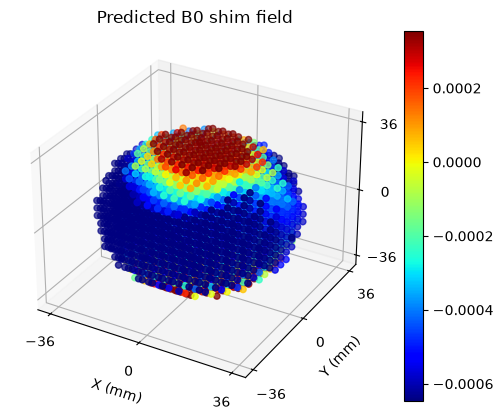

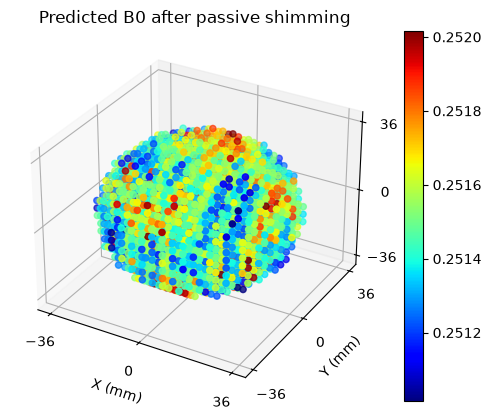


Shimming report — post_shim
Field points: 3071
Mean field: 251.515293 mT
Standard deviation: 207.368 uT (824.48 ppm)
P1-P99 range: 0.879773 mT (3497.89 ppm)
Peak-to-peak field: 3.896437 mT (15491.85 ppm)
Peak-to-peak off-resonance: 165.900 kHz

Objective
  std term: 618.357
  percentile-range term: 874.473
  total cost: 1492.830

Shim population
  active: 204 / 776
  positive: 82
  negative: 122
  absent: 572

Improvement relative to pre-shim
  standard deviation: 64.71%
  robust percentile range: 67.89%
  peak-to-peak ppm: -10.63%
  peak-to-peak off-resonance: -10.56%
  objective cost: 66.64%


PosixPath('data/shimming_runs/20260915_114331/post_shim_report.json')

In [28]:
# Post-shimming report

best_states = optimizer.best_states

B_shim_T = shim_basis.field_from_states(best_states)
B_total_T = field_map.B_T + B_shim_T

field_map_shims_only = FieldMap(
    positions_m=field_map.positions_m,
    B_T=B_shim_T,
    gammabar_Hz_per_T=GAMMABAR_HZ_PER_T,
)
field_map_shims_only.show(title="Predicted B0 shim field")

field_map_shimmed = FieldMap(
    positions_m=field_map.positions_m,
    B_T=B_total_T,
    gammabar_Hz_per_T=GAMMABAR_HZ_PER_T,
)
field_map_shimmed.show(title="Predicted B0 after passive shimming")

post_report = reporter.evaluate(
    B_total_T=B_total_T,
    states=best_states,
    label="post_shim",
)

post_report = reporter.add_improvement(
    pre_report=pre_report,
    post_report=post_report,
)

reporter.print_report(post_report)
reporter.save_report(post_report, run.path("post_shim_report.json"))

# Part VIII — Shim: export magnet collections and STL trays

The final optimized states are converted into physical outputs:

1. optimized Magpylib collections,
2. top and bottom shim-tray STL files,
3. orientation marks and polarity marks.

For workshop build safety and clarity, the default export uses:

```text
orientation marks: yes
positive polarity mark: +
negative polarity mark: none
notch: false
```

Only positive shim magnets receive a visible `+` mark.

In [29]:
# Build and save optimized Magpylib collections

collection_exporter = ShimCollectionExporter(
    candidate_tray=candidate_tray,
    states=best_states,
)

optimized_collections = collection_exporter.build()
collection_exporter.save(output_directory=run.run_dir)

if SHOW_FINAL_COLLECTIONS:
    collection_exporter.show()

print("PASS: optimized collections built and saved.")
print("Run directory:", run.run_dir)


Optimized shim collections
  Active magnets: 204
  Top: 85
  Bottom: 119
  Positive: 82
  Negative: 122


PASS: optimized collections built and saved.
Run directory: data/shimming_runs/20260915_114331


In [31]:
# ============================================================================
# Export physical top and bottom STL trays
#            + add x=0, y=-ymax alignment protrusion
# ============================================================================


tray_exporter = ShimTrayExporter(
    tray_geometry=tray_geometry,
    optimized_collections=optimized_collections,
)

# First export the package-native trays.
tray_exporter.export(
    output_directory=run.run_dir,
    notch=False,
    orientation_marks=True,
    positive_polarity_mark="+",
    negative_polarity_mark=None,
)

print("Base STL trays exported to:")
print(run.run_dir)


# ----------------------------------------------------------------------------
# Add an external alignment protrusion to each exported tray STL
# ----------------------------------------------------------------------------
#
# Purpose:
#   Add a small physical feature at x = 0, y = -ymax on both trays.
#
# Why:
#   This gives participants an obvious visual/tactile landmark for aligning
#   the trays to the magnet coordinate system during attachment.
#
# Geometry:
#   A small rectangular tab is added just outside the -Y edge.
#   It overlaps the tray slightly so slicers treat it as connected.
#
# Notes:
#   - This is intentionally a post-processing step, so we do not need to
#     modify the passive-shimming package internals.
#   - The code auto-detects whether the STL appears to be in meters or mm.
#   - The modified files are saved as *_with_alignment_tab.stl.
#   - The original exported STL files are left unchanged.

ALIGNMENT_TAB_WIDTH_M = 8.0e-3       # size along X
ALIGNMENT_TAB_LENGTH_M = 6.0e-3      # size along Y, protrudes outward
ALIGNMENT_TAB_OVERLAP_M = 1.5e-3     # overlap into tray edge
ALIGNMENT_TAB_HEIGHT_FRACTION = 1.0  # use full tray STL z-thickness


def _infer_stl_length_scale(mesh):
    """
    Infer whether STL coordinates are likely in meters or millimeters.

    Returns
    -------
    scale : float
        Multiply meter-valued design dimensions by this scale to match STL units.
        1.0    -> STL appears to be in meters
        1000.0 -> STL appears to be in millimeters
    unit_label : str
        Human-readable unit label.
    """
    max_extent = float(np.max(mesh.extents))

    # A tray diameter of ~0.2 m would appear as:
    #   ~0.2 if STL units are meters
    #   ~200 if STL units are millimeters
    if max_extent > 10.0:
        return 1000.0, "mm"
    return 1.0, "m"


def add_alignment_tab_to_stl(
    stl_path,
    *,
    tab_width_m=ALIGNMENT_TAB_WIDTH_M,
    tab_length_m=ALIGNMENT_TAB_LENGTH_M,
    tab_overlap_m=ALIGNMENT_TAB_OVERLAP_M,
    tab_height_fraction=ALIGNMENT_TAB_HEIGHT_FRACTION,
):
    """
    Add a small protruding alignment tab at x=0, y=-ymax.

    The output STL is saved next to the input STL as:
        <original_stem>_with_alignment_tab.stl
    """
    stl_path = Path(stl_path)
    mesh = trimesh.load_mesh(stl_path, force="mesh")

    if mesh.is_empty:
        raise ValueError(f"Could not load a valid mesh from {stl_path}")

    scale, unit_label = _infer_stl_length_scale(mesh)

    tab_width = tab_width_m * scale
    tab_length = tab_length_m * scale
    tab_overlap = tab_overlap_m * scale

    bounds = mesh.bounds
    xmin, ymin, zmin = bounds[0]
    xmax, ymax, zmax = bounds[1]

    z_thickness = zmax - zmin
    tab_height = max(z_thickness * tab_height_fraction, 1.0e-6 * scale)

    # Landmark target:
    #   x = 0
    #   y = -ymax / most negative y edge
    #
    # The tab extends outward in -Y while overlapping slightly into the tray.
    tab_center = np.array(
        [
            0.0,
            ymin - tab_length / 2.0 + tab_overlap,
            (zmin + zmax) / 2.0,
        ]
    )

    tab = trimesh.creation.box(
        extents=[
            tab_width,
            tab_length,
            tab_height,
        ],
        transform=trimesh.transformations.translation_matrix(tab_center),
    )

    combined = trimesh.util.concatenate([mesh, tab])

    # Trimesh API has changed across versions.
    # Keep this cleanup conservative so the notebook works across workshop installs.
    try:
        combined.process(validate=True)
    except TypeError:
        combined.process()
    except Exception as exc:
        print(f"Warning: mesh cleanup skipped: {exc}")

    try:
        combined.remove_unreferenced_vertices()
    except Exception as exc:
        print(f"Warning: unreferenced-vertex cleanup skipped: {exc}")

    try:
        combined.fix_normals()
    except Exception as exc:
        print(f"Warning: normal fixing skipped: {exc}")

    output_path = stl_path.with_name(f"{stl_path.stem}_with_alignment_tab.stl")
    combined.export(output_path)

    info = {
        "input_stl": str(stl_path),
        "output_stl": str(output_path),
        "detected_stl_units": unit_label,
        "mesh_bounds": {
            "xmin": float(xmin),
            "xmax": float(xmax),
            "ymin": float(ymin),
            "ymax": float(ymax),
            "zmin": float(zmin),
            "zmax": float(zmax),
        },
        "alignment_feature": {
            "description": "External tab marking x=0, y=-ymax",
            "center": [float(v) for v in tab_center],
            "width": float(tab_width),
            "length": float(tab_length),
            "height": float(tab_height),
        },
    }

    return output_path, info


# Find the newly exported tray STL files.
exported_stls = sorted(
    [
        p for p in Path(run.run_dir).glob("*.stl")
        if "alignment_tab" not in p.stem.lower()
    ]
)

# Also handle uppercase extension if needed.
exported_stls += sorted(
    [
        p for p in Path(run.run_dir).glob("*.STL")
        if "alignment_tab" not in p.stem.lower()
    ]
)

if len(exported_stls) == 0:
    raise FileNotFoundError(
        f"No STL files found in {run.run_dir}. "
        "Check whether ShimTrayExporter.export() completed successfully."
    )

alignment_outputs = []
alignment_manifest = []

for stl_file in exported_stls:
    output_path, info = add_alignment_tab_to_stl(stl_file)
    alignment_outputs.append(output_path)
    alignment_manifest.append(info)

manifest_path = Path(run.run_dir) / "alignment_tab_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(alignment_manifest, f, indent=2)

print("\nAlignment protrusion added to STL trays:")
for path in alignment_outputs:
    print(" ", path.name)

print("\nAlignment manifest saved to:")
print(manifest_path)


if run.stop_after(10):
    raise SystemExit("Stopped after STL export with alignment protrusion.")


Fabricating shim trays
  Geometry mode: circular
  Base geometry: generated circular plates
  Magnet pocket XY clearance: 0.100 mm
  Magnet pocket depth clearance: 0.100 mm
  Notch diameter: 1.500 mm
  Polarity engraving depth: 0.850 mm
  Applying 85 top magnet pocket cutters as one Boolean
    input tray: watertight=True, volume=True
    invalid cutter volumes: 0
    result: watertight=True, volume=True, faces=2480
  Applying 16 top orientation engraving cutters as one Boolean
    input tray: watertight=True, volume=True
    invalid cutter volumes: 0
    result: watertight=True, volume=True, faces=2804
  Applying 68 top polarity engraving cutters as one Boolean
    input tray: watertight=True, volume=True
    invalid cutter volumes: 0
    result: watertight=True, volume=True, faces=4438

Top fabrication input
  Base watertight: True
  Base volume: True
  Base Euler number: -156
  Applying 119 bottom magnet pocket cutters as one Boolean
    input tray: watertight=True, volume=True
   

## Measured post-shim field report

After the shim trays are fabricated and installed, you can measure the shimmed field map and save it as:

```text
./data/shimmed_field_0001.npy
```

This cell loads the measured post-shim field, visualizes it, computes the same report metrics used for the predicted result, and compares the measured improvement against the original pre-shim field.


Measured post-shim field report
-------------------------------
Expected file: data/shimmed_field_0001_sample.npy

Field-map validation passed
  Samples: 1419
  Mean field: 251.130525 mT
  Peak-to-peak: 4.659786 mT
  Peak-to-peak off-resonance: 198.402 kHz

Loaded measured post-shim field map.
Number of measured post-shim points: 1419
Number of original pre-shim points : 3071

Pre-shim positions shape : (3071, 3)
Post-shim positions shape: (1419, 3)
Measured post-shim summary statistics will still be computed.
Direct pointwise comparison will be skipped.


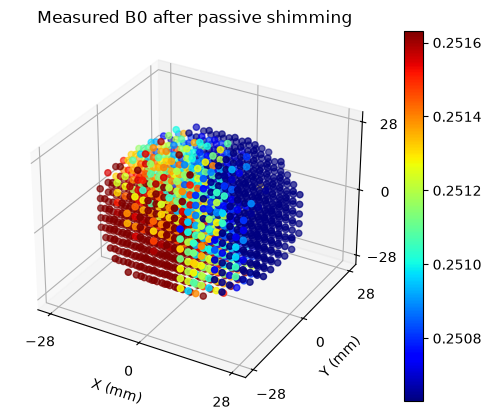


Measured post-shim standalone statistics
----------------------------------------
Points                 : 1419
Mean B0                : 0.251130525 T
Std B0                 : 3292.008 ppm
Std frequency offset   : 35199.807 Hz
P01 / P50 / P99 B0     : -7656.608 / -44.284 / 7440.182 ppm
P01–P99 B0 range       : 15096.790 ppm
P01–P99 frequency range: 161422.492 Hz

Standalone measured statistics above are still valid.
Reason: B_total_T length does not match the field-map sample count.

Distribution-level improvement vs original pre-shim field
---------------------------------------------------------
This comparison does not require matched sample positions.
Pre-shim std B0        : 2336.388 ppm
Post-shim std B0       : 3292.008 ppm
Std improvement        : -40.9%
Pre-shim P01–P99 range : 10891.809 ppm
Post-shim P01–P99 range: 15096.790 ppm
Range improvement      : -38.6%

Prediction-vs-measurement residual skipped.
Reason: predicted and measured fields do not have matching
sample dimens

In [ ]:
# ============================================================================
# Measured post-shim report
# ============================================================================
#
# Workshop use:
#   1. Fabricate/install the exported shim trays.
#   2. Re-measure the B0 field using the same field-mapping workflow if possible.
#   3. Save the measured field map as:
#        ./data/shimmed_field_0001.npy
#      or update SHIMMED_FIELD_FILE below.
#   4. Run this cell to visualize and summarize the measured post-shim result.
#
# Important:
#   This cell still prints measured post-shim statistics even if the post-shim
#   field map has a different number of sample points than the original field map.
#
#   Distribution-level comparisons are allowed when dimensions differ.
#   Direct pointwise residuals are only computed when positions match.

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

SHIMMED_FIELD_FILE = Path("./data/shimmed_field_0001_sample.npy")

print("Measured post-shim field report")
print("-------------------------------")
print("Expected file:", SHIMMED_FIELD_FILE)

if not SHIMMED_FIELD_FILE.exists():
    print("\nMeasured post-shim file not found yet.")
    print("After the group measures the shimmed field, place the file here:")
    print(f"  {SHIMMED_FIELD_FILE}")
    print("\nThen rerun this cell.")

else:
    # ------------------------------------------------------------------------
    # Helper functions
    # ------------------------------------------------------------------------
    def finite_1d(x):
        x = np.asarray(x).ravel()
        return x[np.isfinite(x)]

    def field_stats_from_B_T(B_T, *, label, reference_B_T=None):
        """
        Compute B0 statistics in T, mT, ppm, and Hz.

        mT is reported as field offset from the map's own mean:
            delta_B_mT = (B - mean(B)) * 1e3

        ppm is also reported as field offset from the map's own mean:
            delta_B_ppm = (B - mean(B)) / mean(B) * 1e6

        Hz is reported as frequency offset from the map's own mean:
            delta_f_Hz = (B - mean(B)) * gammabar
        """
        B_T = finite_1d(B_T)

        if B_T.size == 0:
            raise ValueError(f"{label} contains no finite B0 values.")

        mean_B_T = float(np.mean(B_T))

        # Standalone offsets relative to this field map's own mean.
        delta_B_T = B_T - mean_B_T
        delta_B_mT = delta_B_T * 1e3
        delta_B_ppm = delta_B_T / mean_B_T * 1e6
        delta_f_Hz = delta_B_T * GAMMABAR_HZ_PER_T

        p01_mT = float(np.percentile(delta_B_mT, 1))
        p50_mT = float(np.percentile(delta_B_mT, 50))
        p95_mT = float(np.percentile(delta_B_mT, 95))
        p99_mT = float(np.percentile(delta_B_mT, 99))

        p01_ppm = float(np.percentile(delta_B_ppm, 1))
        p50_ppm = float(np.percentile(delta_B_ppm, 50))
        p95_ppm = float(np.percentile(delta_B_ppm, 95))
        p99_ppm = float(np.percentile(delta_B_ppm, 99))

        p01_Hz = float(np.percentile(delta_f_Hz, 1))
        p50_Hz = float(np.percentile(delta_f_Hz, 50))
        p95_Hz = float(np.percentile(delta_f_Hz, 95))
        p99_Hz = float(np.percentile(delta_f_Hz, 99))

        return {
            "label": label,
            "n_points": int(B_T.size),
            "mean_B_T": mean_B_T,
            "mean_B_mT": mean_B_T * 1e3,

            "std_B_T": float(np.std(B_T)),
            "std_delta_B_mT": float(np.std(delta_B_mT)),
            "std_delta_B_ppm": float(np.std(delta_B_ppm)),
            "std_delta_f_Hz": float(np.std(delta_f_Hz)),

            "p01_delta_B_mT": p01_mT,
            "p50_delta_B_mT": p50_mT,
            "p95_delta_B_mT": p95_mT,
            "p99_delta_B_mT": p99_mT,
            "range_p01_p99_delta_B_mT": float(p99_mT - p01_mT),
            "range_p01_p95_delta_B_mT": float(p95_mT - p01_mT),

            "p01_delta_B_ppm": p01_ppm,
            "p50_delta_B_ppm": p50_ppm,
            "p95_delta_B_ppm": p95_ppm,
            "p99_delta_B_ppm": p99_ppm,
            "range_p01_p99_delta_B_ppm": float(p99_ppm - p01_ppm),
            "range_p01_p95_delta_B_ppm": float(p95_ppm - p01_ppm),

            "p01_delta_f_Hz": p01_Hz,
            "p50_delta_f_Hz": p50_Hz,
            "p95_delta_f_Hz": p95_Hz,
            "p99_delta_f_Hz": p99_Hz,
            "range_p01_p99_delta_f_Hz": float(p99_Hz - p01_Hz),
            "range_p01_p95_delta_f_Hz": float(p95_Hz - p01_Hz),

            # Arrays for plotting only; removed before JSON save.
            "_B_T": B_T,
            "_delta_B_mT": delta_B_mT,
            "_delta_B_ppm": delta_B_ppm,
            "_delta_f_Hz": delta_f_Hz,
        }

    def print_field_stats(stats):
        print(f"\n{stats['label']} statistics")
        print("-" * (len(stats["label"]) + 11))
        print(f"Points                       : {stats['n_points']}")
        print(f"Mean B0                      : {stats['mean_B_T']:.9f} T")
        print(f"Mean B0                      : {stats['mean_B_mT']:.6f} mT")

        print("\nB0 offset statistics, centered by this map's mean")
        print(f"Std B0 offset                : {stats['std_delta_B_mT']:.6f} mT")
        print(f"P01 / P50 / P95 / P99        : "
              f"{stats['p01_delta_B_mT']:.6f} / "
              f"{stats['p50_delta_B_mT']:.6f} / "
              f"{stats['p95_delta_B_mT']:.6f} / "
              f"{stats['p99_delta_B_mT']:.6f} mT")
        print(f"P01–P99 B0 range             : {stats['range_p01_p99_delta_B_mT']:.6f} mT")
        print(f"P01–P95 B0 range             : {stats['range_p01_p95_delta_B_mT']:.6f} mT")

        print("\nSame B0 offset statistics in ppm")
        print(f"Std B0 offset                : {stats['std_delta_B_ppm']:.3f} ppm")
        print(f"P01 / P50 / P95 / P99        : "
              f"{stats['p01_delta_B_ppm']:.3f} / "
              f"{stats['p50_delta_B_ppm']:.3f} / "
              f"{stats['p95_delta_B_ppm']:.3f} / "
              f"{stats['p99_delta_B_ppm']:.3f} ppm")
        print(f"P01–P99 B0 range             : {stats['range_p01_p99_delta_B_ppm']:.3f} ppm")
        print(f"P01–P95 B0 range             : {stats['range_p01_p95_delta_B_ppm']:.3f} ppm")

        print("\nSame B0 offset statistics in Hz")
        print(f"Std frequency offset         : {stats['std_delta_f_Hz']:.3f} Hz")
        print(f"P01 / P50 / P95 / P99        : "
              f"{stats['p01_delta_f_Hz']:.3f} / "
              f"{stats['p50_delta_f_Hz']:.3f} / "
              f"{stats['p95_delta_f_Hz']:.3f} / "
              f"{stats['p99_delta_f_Hz']:.3f} Hz")
        print(f"P01–P99 frequency range      : {stats['range_p01_p99_delta_f_Hz']:.3f} Hz")
        print(f"P01–P95 frequency range      : {stats['range_p01_p95_delta_f_Hz']:.3f} Hz")

    def plot_field_scatter_mT(positions_m, delta_B_mT, title):
        """
        Simple robust scatter plot in mT.

        Uses x-y projection when 3D positions are available.
        """
        positions_m = np.asarray(positions_m)
        delta_B_mT = np.asarray(delta_B_mT).ravel()

        if positions_m.ndim != 2 or positions_m.shape[1] < 2:
            print(f"Skipping scatter plot for {title}: positions are not Nx2/Nx3.")
            return

        finite_mask = (
            np.isfinite(positions_m[:, 0])
            & np.isfinite(positions_m[:, 1])
            & np.isfinite(delta_B_mT)
        )

        if np.count_nonzero(finite_mask) == 0:
            print(f"Skipping scatter plot for {title}: no finite points.")
            return

        x_mm = positions_m[finite_mask, 0] * 1e3
        y_mm = positions_m[finite_mask, 1] * 1e3
        c_mT = delta_B_mT[finite_mask]

        vmax = np.percentile(np.abs(c_mT), 99)
        if vmax == 0 or not np.isfinite(vmax):
            vmax = np.max(np.abs(c_mT))
        if vmax == 0 or not np.isfinite(vmax):
            vmax = 1.0

        plt.figure(figsize=(7, 5.5))
        sc = plt.scatter(
            x_mm,
            y_mm,
            c=c_mT,
            s=24,
            cmap="coolwarm",
            vmin=-vmax,
            vmax=vmax,
            edgecolors="none",
        )
        plt.colorbar(sc, label="B0 offset from map mean (mT)")
        plt.xlabel("x position (mm)")
        plt.ylabel("y position (mm)")
        plt.title(title)
        plt.axis("equal")
        plt.grid(True, alpha=0.25)
        plt.show()

    def plot_distribution_mT(stats_list, title):
        """
        Overlay B0-offset histograms in mT.
        Works even when pre/post maps have different dimensions.
        """
        plt.figure(figsize=(8, 5))

        for stats in stats_list:
            delta_B_mT = finite_1d(stats["_delta_B_mT"])
            if delta_B_mT.size == 0:
                continue

            plt.hist(
                delta_B_mT,
                bins=40,
                alpha=0.45,
                density=True,
                label=stats["label"],
            )

        plt.xlabel("B0 offset from each map mean (mT)")
        plt.ylabel("Normalized count")
        plt.title(title)
        plt.grid(True, alpha=0.25)
        plt.legend()
        plt.show()

    def json_safe_report(report):
        """
        Remove non-JSON-safe array fields from the stats dictionary.
        """
        safe = {}
        for key, value in report.items():
            if key.startswith("_"):
                continue
            if isinstance(value, np.generic):
                value = value.item()
            safe[key] = value
        return safe

    # ------------------------------------------------------------------------
    # Load measured post-shim field map
    # ------------------------------------------------------------------------
    measured_post_field_map = FieldMap.from_npy(
        filename=SHIMMED_FIELD_FILE,
        position_scale_to_m=MEASURED_POSITION_SCALE_TO_M,
        field_scale_to_T=MEASURED_FIELD_SCALE_TO_T,
        gammabar_Hz_per_T=GAMMABAR_HZ_PER_T,
    )
    measured_post_field_map.validate()

    print("\nLoaded measured post-shim field map.")
    print("Number of measured post-shim points:", measured_post_field_map.B_T.size)

    if "field_map" in globals():
        print("Number of original pre-shim points :", field_map.B_T.size)

    # ------------------------------------------------------------------------
    # Position compatibility check
    # ------------------------------------------------------------------------
    same_shape = False
    same_positions = False

    if "field_map" in globals():
        same_shape = (
            measured_post_field_map.positions_m.shape
            == field_map.positions_m.shape
        )

        if same_shape:
            same_positions = np.allclose(
                measured_post_field_map.positions_m,
                field_map.positions_m,
                rtol=1e-6,
                atol=1e-9,
            )

        if not same_shape:
            print("\nWARNING: Post-shim field map uses a different sampling shape.")
            print("Pre-shim positions shape :", field_map.positions_m.shape)
            print("Post-shim positions shape:", measured_post_field_map.positions_m.shape)
            print("Measured post-shim summary statistics will still be computed.")
            print("Direct pointwise comparison will be skipped.")

        elif not same_positions:
            max_position_difference_mm = np.max(
                np.linalg.norm(
                    measured_post_field_map.positions_m - field_map.positions_m,
                    axis=1,
                )
            ) * 1e3

            print("\nWARNING: Pre-shim and post-shim positions have the same shape")
            print("but are not identical.")
            print(f"Maximum pointwise position difference: {max_position_difference_mm:.3f} mm")
            print("Measured post-shim summary statistics will still be computed.")
            print("Direct pointwise comparison should be interpreted carefully.")

        else:
            print("\nPosition check: PASS — pre-shim and post-shim positions match.")

    else:
        print("\nOriginal pre-shim field_map object not found.")
        print("Measured post-shim summary statistics will still be computed.")
        print("Improvement relative to pre-shim will be skipped.")

    # ------------------------------------------------------------------------
    # Compute measured post-shim stats
    # ------------------------------------------------------------------------
    measured_post_stats = field_stats_from_B_T(
        measured_post_field_map.B_T,
        label="measured_post_shim",
    )

    print_field_stats(measured_post_stats)

    # ------------------------------------------------------------------------
    # Plot measured post-shim in mT
    # ------------------------------------------------------------------------
    plot_field_scatter_mT(
        measured_post_field_map.positions_m,
        measured_post_stats["_delta_B_mT"],
        title="Measured post-shim B0 offset, centered by post-shim mean",
    )

    # ------------------------------------------------------------------------
    # Optional package-native display
    # This may use package defaults, so the mT plots above are the primary plots.
    # ------------------------------------------------------------------------
    try:
        measured_post_field_map.show(
            title="Measured B0 after passive shimming"
        )
    except Exception as exc:
        print("\nWARNING: FieldMap.show() failed.")
        print("The measured report and mT plots are still valid.")
        print("Reason:", exc)

    # ------------------------------------------------------------------------
    # Try package reporter as before
    # ------------------------------------------------------------------------
    measured_post_report = None

    if "reporter" in globals():
        try:
            measured_post_report = reporter.evaluate(
                B_total_T=measured_post_field_map.B_T,
                states=best_states if "best_states" in globals() else None,
                label="measured_post_shim",
            )

            if "pre_report" in globals():
                measured_post_report = reporter.add_improvement(
                    pre_report=pre_report,
                    post_report=measured_post_report,
                )

            print("\nMeasured post-shim report from notebook reporter")
            print("------------------------------------------------")
            reporter.print_report(measured_post_report)

        except Exception as exc:
            print("\nWARNING: reporter.evaluate() failed.")
            print("Standalone measured statistics above are still valid.")
            print("Reason:", exc)

    else:
        print("\nReporter object not found.")
        print("Standalone measured statistics above are still valid.")

    # ------------------------------------------------------------------------
    # Optional distribution-level improvement relative to original field_map
    # This does NOT require matching sample positions.
    # ------------------------------------------------------------------------
    pre_stats = None

    if "field_map" in globals():
        pre_stats = field_stats_from_B_T(
            field_map.B_T,
            label="pre_shim",
        )

        print_field_stats(pre_stats)

        pre_std_mT = pre_stats["std_delta_B_mT"]
        post_std_mT = measured_post_stats["std_delta_B_mT"]

        pre_range_99_mT = pre_stats["range_p01_p99_delta_B_mT"]
        post_range_99_mT = measured_post_stats["range_p01_p99_delta_B_mT"]

        pre_range_95_mT = pre_stats["range_p01_p95_delta_B_mT"]
        post_range_95_mT = measured_post_stats["range_p01_p95_delta_B_mT"]

        std_improvement_pct = (
            100.0 * (pre_std_mT - post_std_mT) / pre_std_mT
            if pre_std_mT != 0
            else np.nan
        )

        range_99_improvement_pct = (
            100.0 * (pre_range_99_mT - post_range_99_mT) / pre_range_99_mT
            if pre_range_99_mT != 0
            else np.nan
        )

        range_95_improvement_pct = (
            100.0 * (pre_range_95_mT - post_range_95_mT) / pre_range_95_mT
            if pre_range_95_mT != 0
            else np.nan
        )

        print("\nDistribution-level improvement vs original pre-shim field")
        print("---------------------------------------------------------")
        print("This comparison does not require matched sample positions.")
        print(f"Pre-shim std B0 offset            : {pre_std_mT:.6f} mT")
        print(f"Post-shim std B0 offset           : {post_std_mT:.6f} mT")
        print(f"Std improvement                   : {std_improvement_pct:.1f}%")
        print(f"Pre-shim P01–P99 B0 range         : {pre_range_99_mT:.6f} mT")
        print(f"Post-shim P01–P99 B0 range        : {post_range_99_mT:.6f} mT")
        print(f"P01–P99 range improvement         : {range_99_improvement_pct:.1f}%")
        print(f"Pre-shim P01–P95 B0 range         : {pre_range_95_mT:.6f} mT")
        print(f"Post-shim P01–P95 B0 range        : {post_range_95_mT:.6f} mT")
        print(f"P01–P95 range improvement         : {range_95_improvement_pct:.1f}%")

        # Plot pre/post distributions in mT.
        plot_distribution_mT(
            [pre_stats, measured_post_stats],
            title="Pre-shim vs measured post-shim B0 offset distributions",
        )

        # Plot pre-shim spatial map in mT for side-by-side style comparison.
        plot_field_scatter_mT(
            field_map.positions_m,
            pre_stats["_delta_B_mT"],
            title="Pre-shim B0 offset, centered by pre-shim mean",
        )

    # ------------------------------------------------------------------------
    # Optional prediction-vs-measurement residual
    # Only valid when dimensions and positions match.
    # Plotted in mT.
    # ------------------------------------------------------------------------
    residual_stats = None

    if "B_total_T" in globals():
        predicted_B_T = np.asarray(B_total_T).ravel()
        measured_B_T = np.asarray(measured_post_field_map.B_T).ravel()

        can_compare_prediction = (
            predicted_B_T.shape == measured_B_T.shape
            and same_shape
            and same_positions
        )

        if can_compare_prediction:
            predicted_minus_measured_T = predicted_B_T - measured_B_T
            predicted_minus_measured_mT = predicted_minus_measured_T * 1e3

            residual_stats = {
                "label": "prediction_minus_measured_post_shim",
                "n_points": int(predicted_minus_measured_mT.size),
                "rms_delta_B_mT": float(
                    np.sqrt(np.mean(predicted_minus_measured_mT**2))
                ),
                "median_delta_B_mT": float(np.median(predicted_minus_measured_mT)),
                "p01_delta_B_mT": float(np.percentile(predicted_minus_measured_mT, 1)),
                "p50_delta_B_mT": float(np.percentile(predicted_minus_measured_mT, 50)),
                "p95_delta_B_mT": float(np.percentile(predicted_minus_measured_mT, 95)),
                "p99_delta_B_mT": float(np.percentile(predicted_minus_measured_mT, 99)),
                "range_p01_p99_delta_B_mT": float(
                    np.percentile(predicted_minus_measured_mT, 99)
                    - np.percentile(predicted_minus_measured_mT, 1)
                ),
                "range_p01_p95_delta_B_mT": float(
                    np.percentile(predicted_minus_measured_mT, 95)
                    - np.percentile(predicted_minus_measured_mT, 1)
                ),
            }

            print("\nPrediction-vs-measurement residual")
            print("----------------------------------")
            print(f"RMS residual                  : {residual_stats['rms_delta_B_mT']:.6f} mT")
            print(f"Median residual               : {residual_stats['median_delta_B_mT']:.6f} mT")
            print(
                "P01 / P50 / P95 / P99 residual: "
                f"{residual_stats['p01_delta_B_mT']:.6f} / "
                f"{residual_stats['p50_delta_B_mT']:.6f} / "
                f"{residual_stats['p95_delta_B_mT']:.6f} / "
                f"{residual_stats['p99_delta_B_mT']:.6f} mT"
            )
            print(
                "P01–P99 residual range        : "
                f"{residual_stats['range_p01_p99_delta_B_mT']:.6f} mT"
            )
            print(
                "P01–P95 residual range        : "
                f"{residual_stats['range_p01_p95_delta_B_mT']:.6f} mT"
            )

            plot_field_scatter_mT(
                measured_post_field_map.positions_m,
                predicted_minus_measured_mT,
                title="Prediction minus measured post-shim B0 residual",
            )

        else:
            print("\nPrediction-vs-measurement residual skipped.")
            print("Reason: predicted and measured fields do not have matching")
            print("sample dimensions and identical positions.")
            print("Predicted B_total_T shape:", predicted_B_T.shape)
            print("Measured post-shim shape :", measured_B_T.shape)

    # ------------------------------------------------------------------------
    # Save measured report
    # ------------------------------------------------------------------------
    report_to_save = {
        "standalone_measured_post_shim_stats": json_safe_report(measured_post_stats),
        "pre_shim_stats": json_safe_report(pre_stats) if pre_stats is not None else None,
        "prediction_minus_measured_residual_stats": residual_stats,
        "reporter_measured_post_shim_report": measured_post_report,
        "same_shape_as_pre_shim": bool(same_shape),
        "same_positions_as_pre_shim": bool(same_positions),
        "units_note": {
            "mT": "Reported as B0 offset from each field map mean unless explicitly noted.",
            "ppm": "Reported as B0 offset from each field map mean divided by that map mean.",
            "Hz": "Reported as frequency offset from each field map mean using GAMMABAR_Hz_per_T.",
        },
    }

    if "run" in globals():
        measured_report_file = run.path("measured_post_shim_report.json")
    else:
        measured_report_file = Path("./measured_post_shim_report.json")

    with open(measured_report_file, "w") as f:
        json.dump(report_to_save, f, indent=2)

    print("\nSaved measured post-shim report to:")
    print(" ", measured_report_file)

# Final workshop assignment

## Assignment: explain and refine one passive-shimming design choice

Pick one of the following and write a short response in the team discussion thread.

### Option A — MR shimming interpretation

Compare the pre-shim and post-shim reports.

Answer:

1. Which metric improved most?
2. Did the shim field reduce the broad field trend or mostly local variation?
3. Would you trust this tray for a first physical test? Why or why not?

### Option B — Greedy versus genetic search

Change one optimization parameter:

```python
POPULATION_SIZE
NUM_GENERATIONS
PERTURBATION_SIZES
STD_WEIGHT
P01_P99_WEIGHT
```

Answer:

1. Did the best solution improve?
2. Did the selected magnet pattern change substantially?
3. Was the longer computation worth it?

### Option C — Tray geometry

Compare:

```python
USE_EXTERNAL_STL = True
```

with:

```python
USE_EXTERNAL_STL = False
```

Answer:

1. How did the candidate count change?
2. Did the achievable shim quality change?
3. Why does physical tray geometry matter?

---

## Discussion prompt

Passive shimming is not just optimization. It connects:

```text
measured field map → candidate magnet physics → search algorithm → physical tray design → safer scanner testing
```

Post your best plot, one insight, and one question for the mentor team.